In [53]:
import numpy as np

In [54]:
import pandas as pd

In [55]:
close_px_all = pd.read_csv("examples/stock_px.csv", parse_dates = True, index_col = 0)

In [56]:
close_px = close_px_all[["AAPL", "MSFT", "XOM"]]

In [57]:
close_px = close_px.resample("B").ffill()

<Axes: >

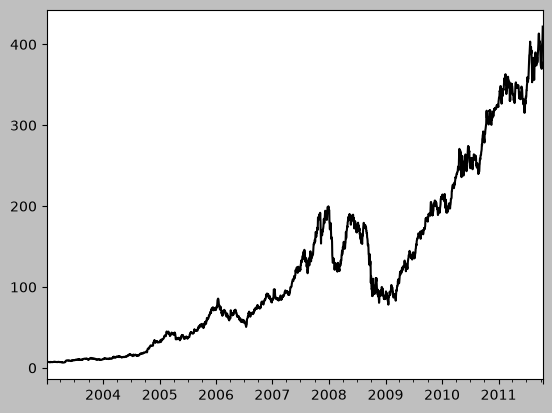

In [58]:
close_px["AAPL"].plot()

<Axes: >

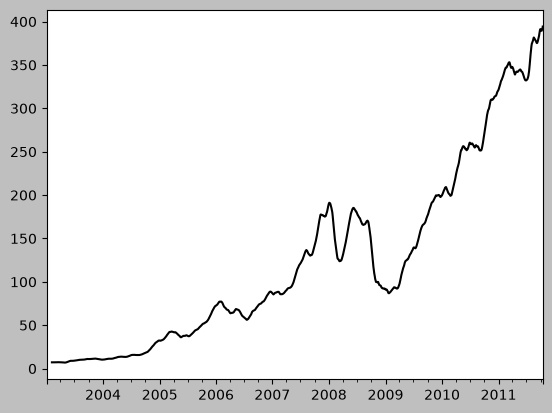

In [59]:
close_px["AAPL"].rolling(25).mean().plot()

In [60]:
std250 = close_px["AAPL"].pct_change().rolling(250, min_periods=10).std()

In [61]:
std250[5:12]

2003-01-09         NaN
2003-01-10         NaN
2003-01-13         NaN
2003-01-14         NaN
2003-01-15         NaN
2003-01-16    0.009628
2003-01-17    0.013818
Freq: B, Name: AAPL, dtype: float64

In [62]:
expanding_mean = std250.expanding().mean()

In [63]:
import matplotlib.pyplot as plt

In [64]:
plt.style.use('grayscale')

<Axes: >

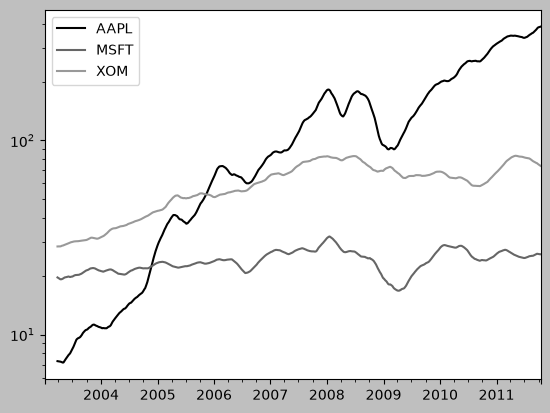

In [65]:
close_px.rolling(60).mean().plot(logy = True)

In [66]:
close_px.rolling("20D").mean()

,AAPL,MSFT,XOM
2003-01-02,7.400000,21.110000,29.220000
2003-01-03,7.425000,21.125000,29.230000
2003-01-06,7.433333,21.256667,29.473333
2003-01-07,7.432500,21.425000,29.342500
2003-01-08,7.402000,21.402000,29.240000
...,...,...,...
2011-10-10,389.351429,25.602143,72.527857
2011-10-11,388.505000,25.674286,72.835000
2011-10-12,388.531429,25.810000,73.400714
2011-10-13,388.826429,25.961429,73.905000


In [67]:
appl_px = close_px["AAPL"]["2006":"2007"]

In [68]:
ma30 = appl_px.rolling(30, min_periods=20).mean()

In [69]:
ewma30 = appl_px.ewm(span=30).mean()

<Axes: >

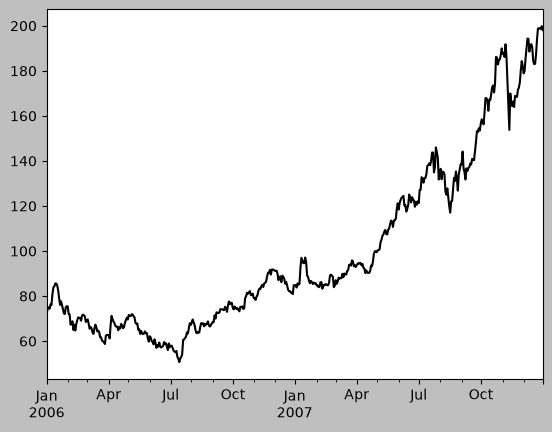

In [70]:
appl_px.plot(style = "k-", label = "Price")

<Axes: >

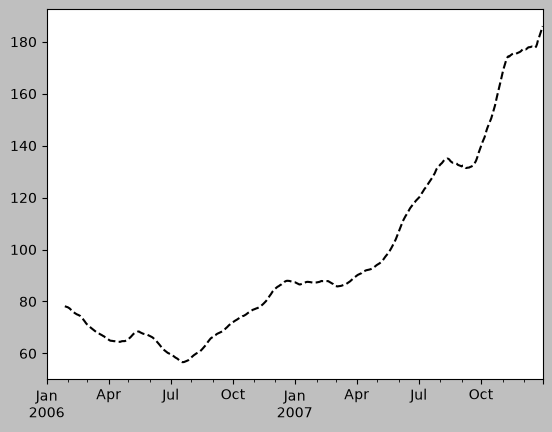

In [71]:
ma30.plot(style = "k--",label = "simple moving avg")

<Axes: >

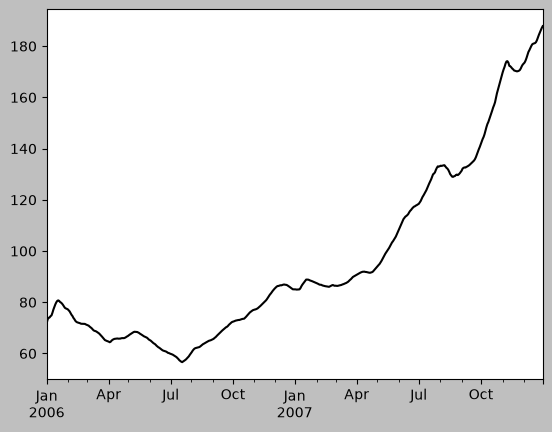

In [72]:
ewma30.plot(style = "k-", label = "EW MA")

C:\Users\Ahem\AppData\Local\Temp\ipykernel_17736\4061938096.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


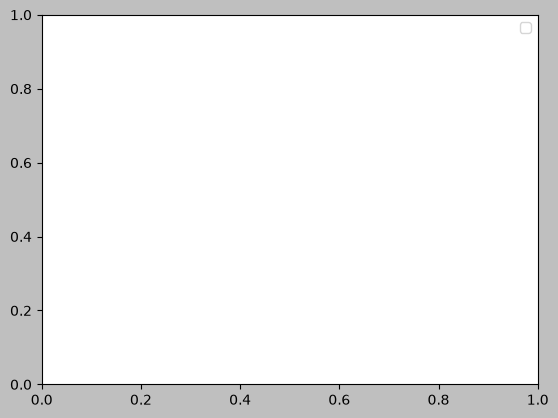

In [73]:
plt.legend()

In [74]:
spx_px = close_px_all["SPX"]

In [75]:
spx_rets = spx_px.pct_change()

In [76]:
returns = close_px.pct_change()

In [77]:
corr = returns["AAPL"].rolling(125, min_periods = 100).corr(spx_rets)

<Axes: >

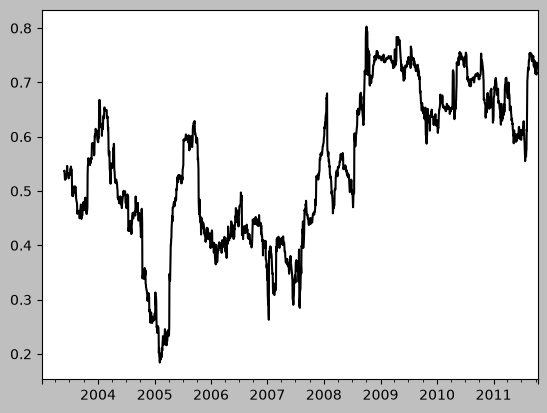

In [78]:
corr.plot()

In [81]:
corr = returns.rolling(125, min_periods = 100).corr(spx_rets)

<Axes: >

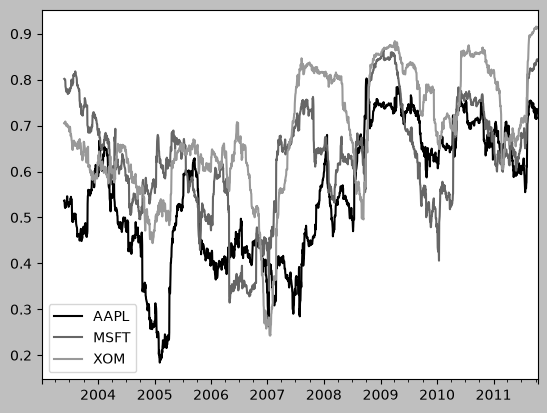

In [82]:
corr.plot()

In [83]:
from scipy.stats import percentileofscore

In [84]:
def scoreat2percent(x):
    return percentileofscore(x, 0.02)

In [85]:
result = returns["AAPL"].rolling(250).apply(scoreat2percent)

<Axes: >

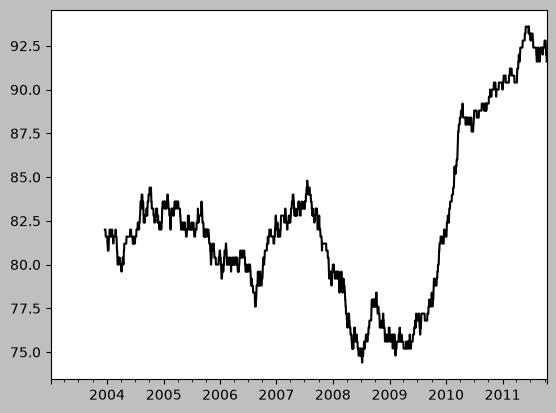

In [87]:
result.plot()